In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

import matplotlib as matp
matp.rcParams['mathtext.fontset'] = 'stix'
matp.rcParams['font.family'] = 'STIXGeneral'

In [179]:
def feasible(x, D, beta):
    return gamma.pdf(x, (D+1)/2, loc = 0, scale = 1/beta)

def infeasible(x, D, beta, disp, scaler):
    return scaler[0]*gamma.pdf(x, (D[0]+1)/2, loc = disp[0], scale = 1/beta[0]) + scaler[1]*gamma.pdf(x, (D[1]+1)/2, loc = disp[1], scale = 1/beta[1]) + scaler[2]*gamma.pdf(x, (D[2]+1)/2, loc = disp[2], scale = 1/beta[2])

def plot_lower_riemann(ax, x, y, block=5):
    n = len(x) - (len(x) % block)
    for i in range(0, n - block, block):
        x_left = x[i]
        width = x[i + block] - x[i]
        height = np.min(y[i:i + block])
        ax.bar(x_left, height, width=width, align='edge', color = "#9367bd", alpha = .5)    

def plot_upper_riemann(ax, x, y, block=5):
    n = len(x) - (len(x) % block)
    for i in range(0, n - block, block):
        x_left = x[i]
        width = x[i + block] - x[i]
        height = np.max(y[i:i + block])
        ax.bar(x_left, height, width=width, align='edge', color = "#9367bd", alpha = .5)    

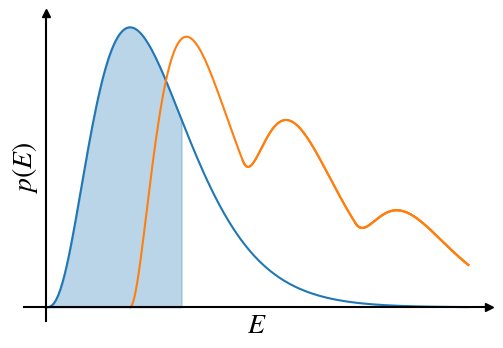

In [115]:
Df, betaf, Ef_idx = 7, 1, 65
Dif, betaif, disp, scaler = [5, 5, 5], [1,1,1], [3, 7, 11], [.8, .4, .2]
xmax = 15
xf = np.linspace(0, xmax, 200)
xif = np.linspace(disp, xmax, 200)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)
ax.set_ylabel("$p(E)$", fontsize = 20)
ax.set_xlabel("$E$", fontsize = 20)
ax.plot(xf, feasible(xf, Df, betaf), color = "C0")
plt.fill_between(xf[:Ef_idx], feasible(xf[:Ef_idx], Df, betaf), color='C0', alpha=0.3)

ax.plot(xif, infeasible(xif, Dif, betaif, disp, scaler), color = "C1")


# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Move bottom and left spines to zero
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')

# Remove ticks if you want a clean look
ax.set_xticks([])
ax.set_yticks([])

# Add arrows
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

# Make axis lines thicker
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)


# ax.set_xlim(0, 1)
# ax.set_ylim(0, 1)
plt.show()

# fig.savefig("plots_paper/Fig1/total.pdf", format = "pdf")

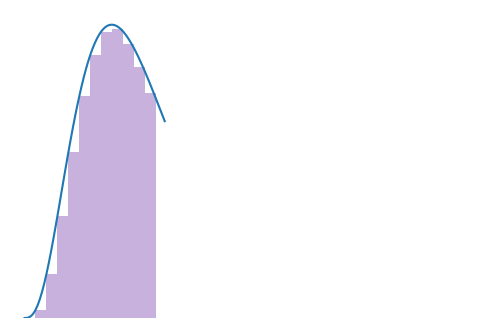

In [183]:
Df, betaf, Ef_idx = 7, 1, 65
xmax = 15
xf = np.linspace(0, xmax, 200)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)

ax.plot(xf[:Ef_idx], feasible(xf[:Ef_idx], Df, betaf), color = "C0")
# plt.fill_between(xf[:Ef_idx], feasible(xf[:Ef_idx], Df, betaf), color='C0', alpha=0.3)
plot_lower_riemann(ax, xf[:Ef_idx], feasible(xf[:Ef_idx], Df, betaf), 5)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# ax.spines['bottom'].set_position('zero')
# ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
# ax.spines['bottom'].set_linewidth(1.5)

# Remove ticks if you want a clean look
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-.5,15.5)

plt.show()

fig.savefig("plots_paper/Fig1/f_head.pdf", format = "pdf")

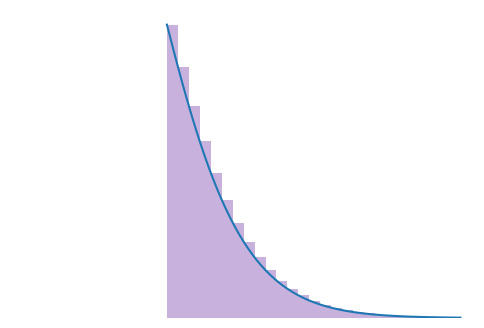

In [184]:
Df, betaf, Ef_idx = 7, 1, 65
xmax = 15
xf = np.linspace(0, xmax, 200)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)

ax.plot(xf[Ef_idx:], feasible(xf[Ef_idx:], Df, betaf), color = "C0")
plot_upper_riemann(ax, xf[Ef_idx:], feasible(xf[Ef_idx:], Df, betaf), block=5)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# ax.spines['bottom'].set_position('zero')
# ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
# ax.spines['bottom'].set_linewidth(1.5)

# Remove ticks if you want a clean look
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-.5,15.5)

plt.show()

fig.savefig("plots_paper/Fig1/f_tail.pdf", format = "pdf")

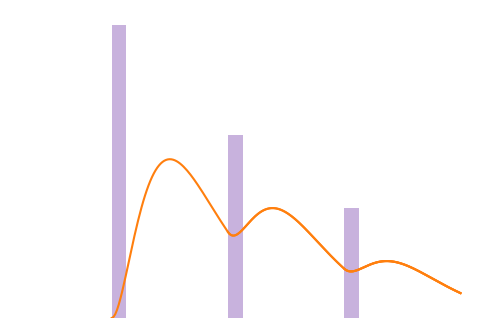

In [185]:
Dif, betaif, disp, scaler = [5, 5, 5], [1,1,1], [3, 7, 11], [.8, .4, .2]
xmax = 15
xif = np.linspace(disp, xmax, 200)

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111)

heights = [.4, .25, .15]

ax.plot(xif, infeasible(xif, Dif, betaif, disp, scaler), color = "C1")
for i, dis in enumerate(disp):
    x_left = dis
    width = .5
    ax.bar(x_left, heights[i], width=width, align='edge', color = "#9367bd", alpha = .5)    

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# ax.spines['bottom'].set_position('zero')
# ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
# ax.spines['bottom'].set_linewidth(1.5)

# Remove ticks if you want a clean look
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-.5,15.5)

plt.show()

fig.savefig("plots_paper/Fig1/inf.pdf", format = "pdf")